In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pandas as pd


In [2]:
X,y= make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [3]:
X.shape

(1000, 2)

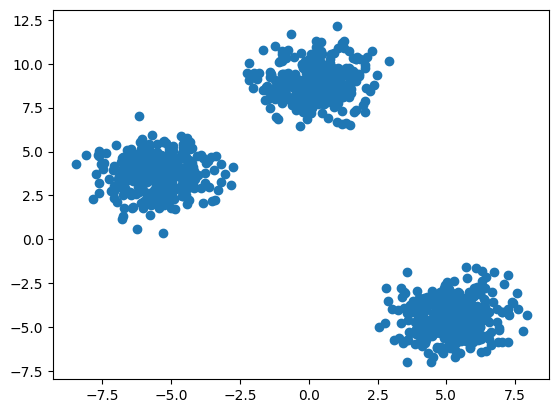

In [4]:
from matplotlib import pyplot as plt
plt.scatter(X[:,0],X[:,1])

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.33,random_state=42)


In [16]:
## Manual Process
# Elbow Method to select the k value

wcss=[]
for k in range(1,11):
    kmeans= KMeans(n_clusters=k,init ='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)


In [17]:
wcss

[34827.57682552022,
 7935.437286145416,
 1319.2730531585607,
 1184.7410922007766,
 1071.895773843384,
 869.1694084149486,
 783.0116803058953,
 804.4925665199236,
 585.9242166753484,
 595.9122841511611]

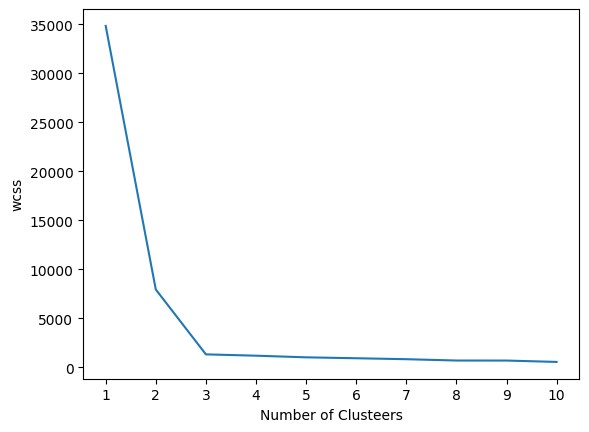

In [9]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusteers")
plt.ylabel("wcss")
plt.show()

In [10]:
model=KMeans(n_clusters=3)
ylabels=model.fit_predict(x_train)

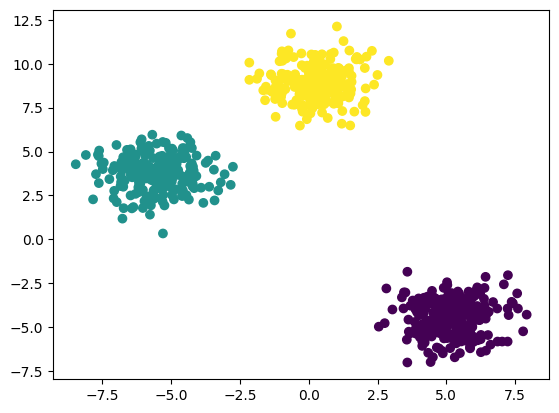

In [11]:
plt.scatter(x_train[:,0],x_train[:,1],c=ylabels)

In [13]:
from kneed import KneeLocator

In [20]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [21]:
kl.elbow

np.int64(3)

In [22]:
from sklearn.metrics import silhouette_score

In [23]:
silhouette_coefficient=[]
for k in range(2,11):
    kmeans= KMeans(n_clusters=k,init ='k-means++')
    kmeans.fit(x_train)
    score= silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficient.append(score)


In [24]:
silhouette_coefficient

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.6494505239910743,
 0.5015384281667714,
 0.4774156963135726,
 0.3431709870797025,
 0.3444059336655824,
 0.3375857191075454]

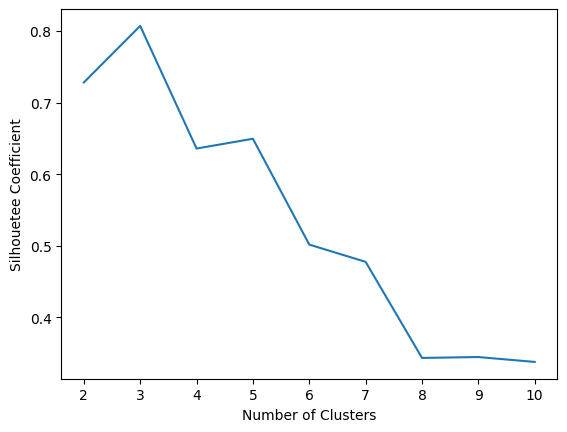

In [26]:
plt.plot(range(2,11),silhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouetee Coefficient")
plt.show()